# Lab 6.1 Fine-Tuning

In this notebook you will explore fine-tuning a CNN to classify pet breeds.

In [12]:
import torch
device = 'cuda'

Here is some code to download a prepared version of the [Oxford-IIIT Pet dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/).

In [13]:
!wget -q -nc -O oxford_pets.zip "https://www.dropbox.com/scl/fi/p49ifha27c2u3uptfj42w/oxford_pets_corrected.zip?rlkey=dwk3dsptzir8v846imsq6bgw3&dl=1"
!unzip -n -qq oxford_pets.zip
!pip install torchmetrics

In [14]:
import torch
import torch.nn as nn
import torchvision
import torchmetrics
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm

The following code sets up dataset and dataloaders for the data.  It creates two versions: the `no_transform` version does not apply any transformations, and the other one applies the appropriate transformations for the VGG16 model (resize, recropping, centering, and scaling).

In [15]:
transforms = torchvision.models.VGG16_Weights.IMAGENET1K_V1.transforms()

train_ds_no_transform = torchvision.datasets.ImageFolder(
    'oxford_pets/train',
)
train_ds = torchvision.datasets.ImageFolder(
    'oxford_pets/train',
    transform=transforms
)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
test_ds_no_transform = torchvision.datasets.ImageFolder(
    'oxford_pets/test',
)
test_ds = torchvision.datasets.ImageFolder(
    'oxford_pets/test',
    transform=transforms
)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

In [16]:
train_ds

Dataset ImageFolder
    Number of datapoints: 6639
    Root location: oxford_pets/train
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           )

Text(0.5, 1.0, 'Abyssinian')

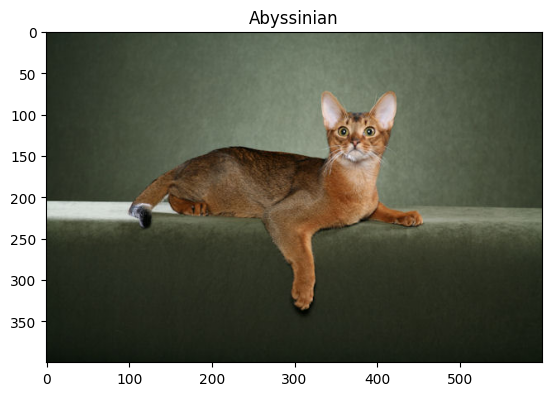

In [17]:
image,label = next(iter(train_ds_no_transform))
plt.imshow(image)
plt.title(train_ds.classes[label])

Now we will grab the VGG16 model with pretrained weights.

In [22]:
vgg16 = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1).to(device)

In [19]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Exercises

1. Iterate through the parameters of the `features` part of VGG16 and set `requires_grad=False` on each parameter.

In [23]:
for parameter in vgg16.features.parameters():
  parameter.requires_grad = False

2. Replace the `classifier` part of the network with a new `Sequential` model that has 35 outputs for the 35 pet breeds.

*Note:* You can do `vgg16.classifier = nn.Sequential(...).to(device)`.

In [24]:
vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 35)
).to(device)

3. Use the following code to check the test set accuracy of the model *before* training it.  Interpret the result.

In [25]:
metric = torchmetrics.Accuracy('multiclass',num_classes=35).to(device)
metric.reset()
for x_batch, y_batch in test_loader:
    y_pred = vgg16(x_batch.to(device))
    metric(y_pred, y_batch.to(device))
metric.compute()

tensor(0.0352, device='cuda:0')

The untrained model correctly predicted about 3.52% of the test images.

5. Now train the model on the training set for three epochs.

In [26]:
import torch.optim as optim

# Only optimize the new classifier layers.
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=0.001)
loss_function = nn.CrossEntropyLoss()

# Train for three epochs.
for epoch in range(3):
    vgg16.train()

    train_loss = 0.0
    train_metric = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=35
    ).to(device)

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = vgg16(x_batch)
        loss = loss_function(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_metric.update(y_pred, y_batch)

    average_loss = train_loss / len(train_loader)
    accuracy = train_metric.compute()

    print(
        f"Epoch {epoch + 1}/3 | "
        f"Loss: {average_loss:.4f} | "
        f"Training accuracy: {accuracy:.4f}"
    )

Epoch 1/3 | Loss: 1.6520 | Training accuracy: 0.5901
Epoch 2/3 | Loss: 0.8923 | Training accuracy: 0.7848
Epoch 3/3 | Loss: 0.9384 | Training accuracy: 0.8199


6. Evaluate the accuracy of the fine-tuned model on the test set.

In [27]:
vgg16.eval()

test_metric = torchmetrics.Accuracy(
    task="multiclass",
    num_classes=35
).to(device)

test_metric.reset()

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = vgg16(x_batch)
        test_metric.update(y_pred, y_batch)

test_accuracy = test_metric.compute()
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.8119


7. The following code will show some test images with the correct and predicted labels.

In [28]:
vgg16.eval()
preds = []
for x_batch, y_batch in test_loader:
    y_pred = vgg16(x_batch.to(device))
    y_pred = torch.argmax(y_pred,dim=-1)
    preds.append(y_pred.detach().cpu().numpy())
preds = np.concatenate(preds,axis=0)

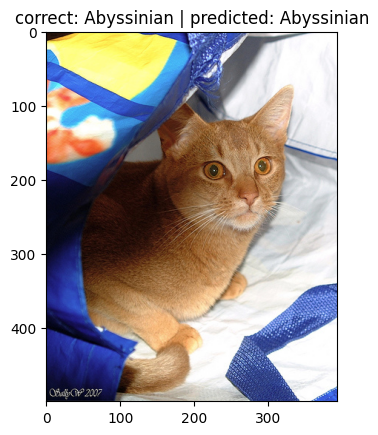

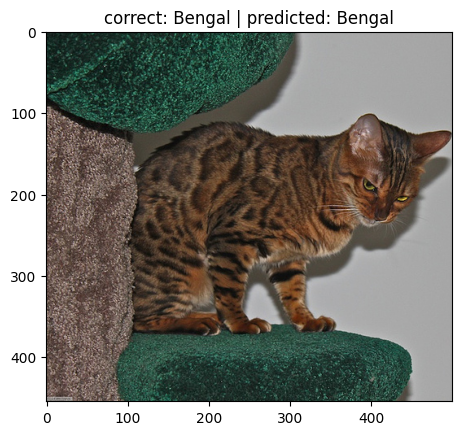

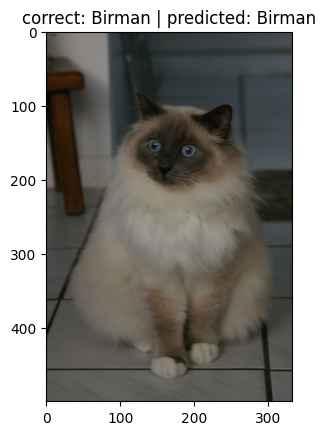

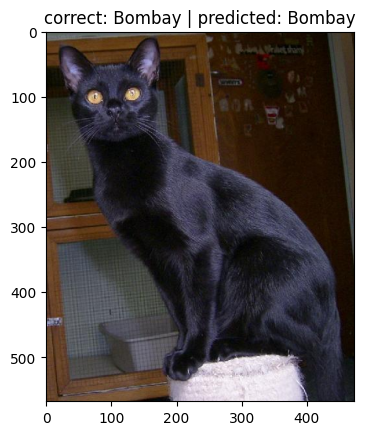

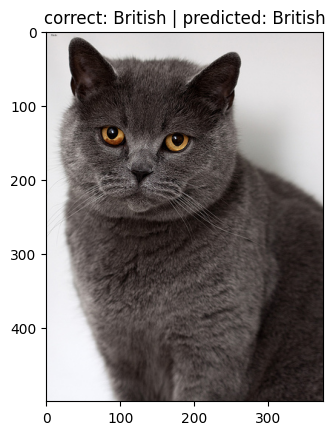

...

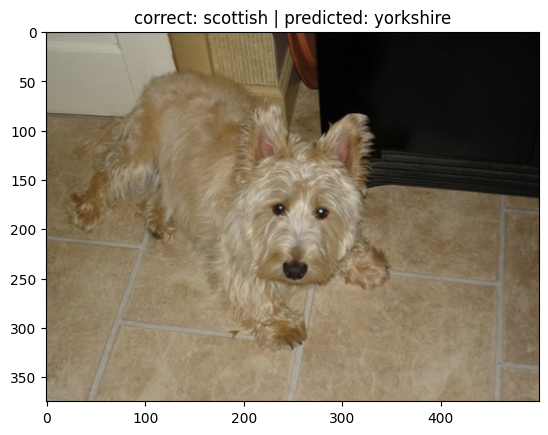

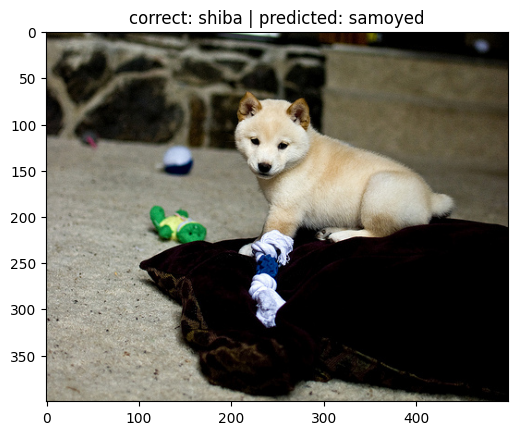

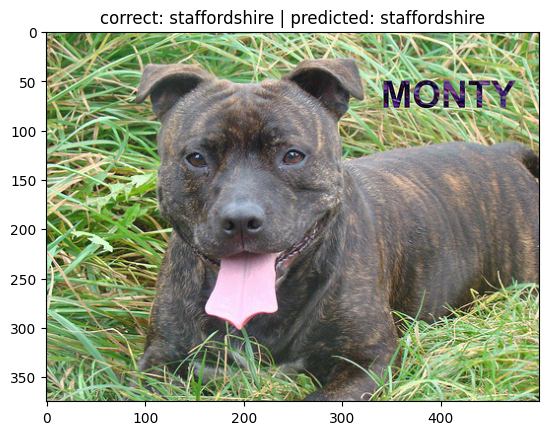

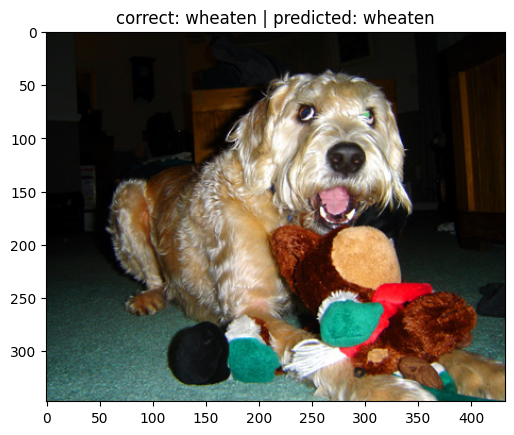

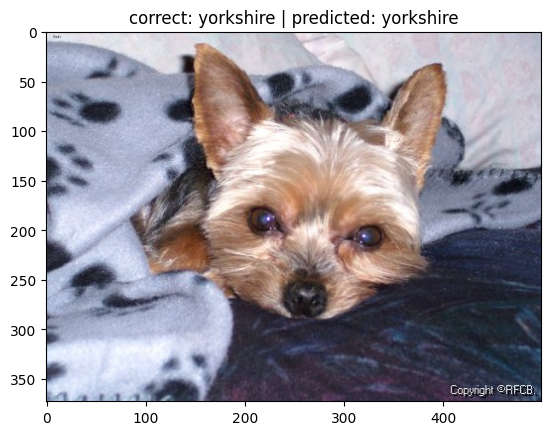

In [29]:
i = 0
for (im,label),pred in zip(test_ds_no_transform,preds):
  if i%20 == 0:
    plt.imshow(im)
    plt.title(f'correct: {test_ds.classes[label]} | predicted: {test_ds.classes[pred]}')
    plt.show()
  i += 1